# The Fourth Circle: Neural Networks, Part Two 
## Convolutional Neural Networks III

<br/>
Jiří Fejlek

2026-02-12
<br/>


## Table of Contents

- [VGGNet](#vgg)
    - [Training VGGNet on Fashion-MNIST](#vggnet_fashion_mnist)
    - [Training VGGNet on CIFAR-10](#vggnet_cifar_10)
- [Batch Normalization](#batch_norm)
- [References](#references)

In this next smaller project, in which we cover various convolutional neural networks, we will have a look at VGGNets developed by Visual Geometry Group (VGG) at the University of Oxford in 2014.


## VGGNet <a class="anchor" id="vgg"></a>

In the last project, we introduced AlexNet [[1](#1)], the first truly large convolutional network with over 60 million parameters trained using 2 GPUs. AlexNet starts with convolutional layers with 11x11 and 5x5 kernels, each followed by max-pooling. However, the issue with immediately following the convolutional layer with downsampling is that it rapidly reduces the image size, which limits the number of layers that can be stacked one after another, i.e., this approach limits the depth of the neural network. Now, the AlexNet architecture respects that observation: after these two convolution + downsampling layers, it continues with a block of 3x3 convolutional layers with 1-pixel padding and a stride of 1. Notice that such 3x3 layers do not decrease the size of the image. In addition, by stacking these layers, we effectively increase the *receptive field* of the resulting block (a stack of two has an effective receptive field of 5×5, a stack of three has 7x7, etc.). In other words, these blocks perform a similar function to a convolution layer with a large kernel. But these blocks are *deeper* and consequently more nonlinear (due to multiple applications of activation functions).

VGGNet [[2](#2)] leverages this observation and consists of stacked 3x3 convolutional layers, resulting in significantly deeper convolutional neural networks that can often outperform AlexNet. Crucially, VGGNet also provides a more intuitive framework for building our own networks for a specific image dataset than AlexNet ever did. 

First, let us implement the block of 3x3 convolutional layers.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import torchvision
import torch

from torch import nn
from torch.utils.data import DataLoader

np.set_printoptions(legacy='1.25')

In [2]:
def layer_summary(nn_model, X_shape):
    X = torch.randn(*X_shape)
    for layer in nn_model.net_stack:
        X = layer(X)
        print(layer.__class__.__name__, 'output shape:\t', X.shape)

In [3]:
def VGG_block(num_convs, out_channels):
    layers = []
    for _ in range(num_convs):
        layers.append(nn.LazyConv2d(out_channels, kernel_size = 3, padding = 1))
        layers.append(nn.ReLU())
    layers.append(nn.MaxPool2d(kernel_size = 2,stride = 2))
    return nn.Sequential(*layers)

The resulting VGGNet is then a combination of *VGGblock*s with fully connected linear layers that perform the classification itself [[2](#2)].

In [4]:
class VGG(nn.Module):
    def __init__(self, VGG_arch, num_full, num_classes):
        super().__init__()
        
        vgg_blocks = []
        for (num_convs, out_channels) in VGG_arch:
            vgg_blocks.append(VGG_block(num_convs, out_channels))
            
        self.net_stack = nn.Sequential(
            *vgg_blocks, nn.Flatten(),
            nn.LazyLinear(num_full), nn.ReLU(), nn.Dropout(0.5),
            nn.LazyLinear(num_full), nn.ReLU(), nn.Dropout(0.5),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

There are several VGGNet  architectures in  [[1](#1)], the simplest one is known as VGG-11 (denoted as A in [[1](#1)]).

In [5]:
layer_summary(VGG(VGG_arch = ((1,64),(1,128),(2,256),(2,512),(2,512)), num_full = 4096, num_classes = 10),(1,1,224,224))

Sequential output shape:	 torch.Size([1, 64, 112, 112])
Sequential output shape:	 torch.Size([1, 128, 56, 56])
Sequential output shape:	 torch.Size([1, 256, 28, 28])
Sequential output shape:	 torch.Size([1, 512, 14, 14])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
Flatten output shape:	 torch.Size([1, 25088])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 10])


Other popular variants, VGG-16 (denoted as D in [[1](#1)]) and VGG-19 (denoted as E in [[1](#1)]), both of which have a slightly higher number of convolutions in the blocks.

In [6]:
# VGG16
layer_summary(VGG(VGG_arch = ((2,64),(2,128),(3,256),(3,512),(3,512)), num_full = 4096, num_classes = 10),(1,1,224,224))

Sequential output shape:	 torch.Size([1, 64, 112, 112])
Sequential output shape:	 torch.Size([1, 128, 56, 56])
Sequential output shape:	 torch.Size([1, 256, 28, 28])
Sequential output shape:	 torch.Size([1, 512, 14, 14])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
Flatten output shape:	 torch.Size([1, 25088])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 10])


In [7]:
# VGG19
layer_summary(VGG(VGG_arch = ((2,64),(2,128),(4,256),(4,512),(4,512)), num_full = 4096, num_classes = 10),(1,1,224,224))

Sequential output shape:	 torch.Size([1, 64, 112, 112])
Sequential output shape:	 torch.Size([1, 128, 56, 56])
Sequential output shape:	 torch.Size([1, 256, 28, 28])
Sequential output shape:	 torch.Size([1, 512, 14, 14])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
Flatten output shape:	 torch.Size([1, 25088])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 10])


### Training VGGNet on Fashion-MNIST <a class="anchor" id="vggnet_fashion_mnist"></a>

Let us train VGG-11 on the Fashion MNIST dataset [[3](#3)]. We will first use the full neural network on upscaled 224x224 images.

In [8]:
transforms_fashion_mnist =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([224,224]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist)

VGG-11 is even larger than AlexNet in terms of the number of trainable parameters, and hence, we will train VGG-11 on a GPU.

In [9]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 4070 Ti'

In [10]:
cuda_device = torch.device('cuda')
VGGNet11_cuda = VGG(VGG_arch = ((1,64),(1,128),(2,256),(2,512),(2,512)), num_full = 4096, num_classes = 10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
VGGNet11_cuda(x);

Specifically, the number of parameters is as follows.

In [11]:
sum(p.numel() for p in VGGNet11_cuda.parameters() if p.requires_grad)

128806154

This is twice as much as AlexNet. Lastly, we need to initialize the weights and define the training loop.

In [12]:
def init_weights_he(model):
    if isinstance(model, nn.Linear):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0) 
    if isinstance(model, nn.Conv2d):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0)   

In [13]:
def train_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    accu_sum_train = 0
    size_train = 0

    
    for batch, (X, y) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        y = y.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits = model(X) # forward pass
        loss = loss_fn(pred_logits, y) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
            accu_sum_train = accu_sum_train + ((softmax(pred_logits).argmax(dim = 1)-y).abs() == 0).long().sum()

    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        accu_sum_train = accu_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        accu_sum_test = 0
        size_test = 0
        
        for batch, (X_test, y_test) in enumerate(test_data_loader):

            X_test = X_test.to(cuda_device)
            y_test = y_test.to(cuda_device)
            
            pred_logits_test = model(X_test)
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test, y_test)*len(X_test)
            accu_sum_test = accu_sum_test + ((softmax(pred_logits_test).argmax(dim = 1)-y_test).abs() == 0).long().sum()
            size_test = size_test + len(X_test)
            
        loss_sum_test = loss_sum_test/size_test
        accu_sum_test = accu_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0], accu_sum_train.detach(), accu_sum_test.detach()

Since VGGNet-11 is a much larger network than AlexNet, we will reduce the batch size. We will also train for only 25 epochs to reduce training time. Other than that, we will use the same hyperparameter values as in training AlexNet.

In [14]:
fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 100, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 100, shuffle = False) 

torch.manual_seed(123)
VGGNet11_cuda.apply(init_weights_he) 
optim_SGD_cuda =  torch.optim.SGD(VGGNet11_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.005)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[15, 20], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss()

n_epochs = 25

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)
loss = nn.CrossEntropyLoss()

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, VGGNet11_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

4162.410778999329


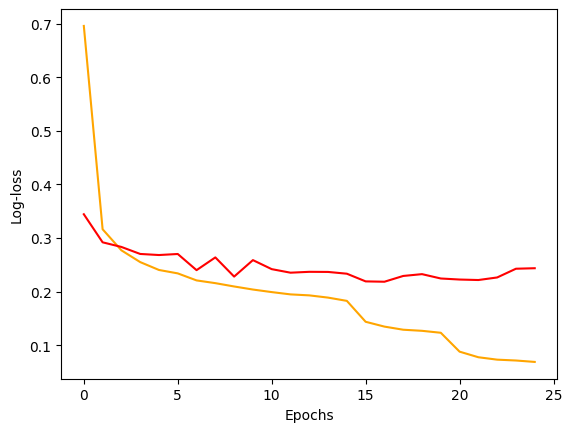

In [15]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

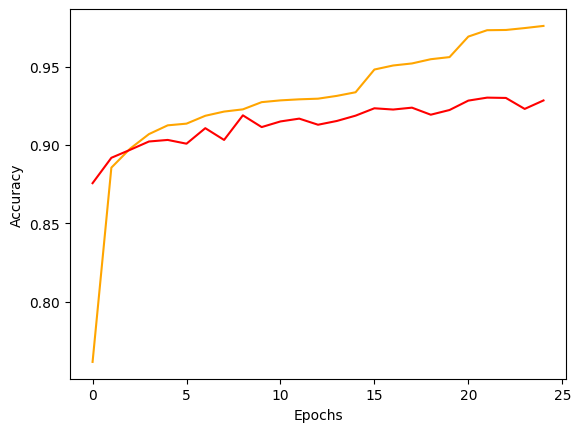

In [16]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

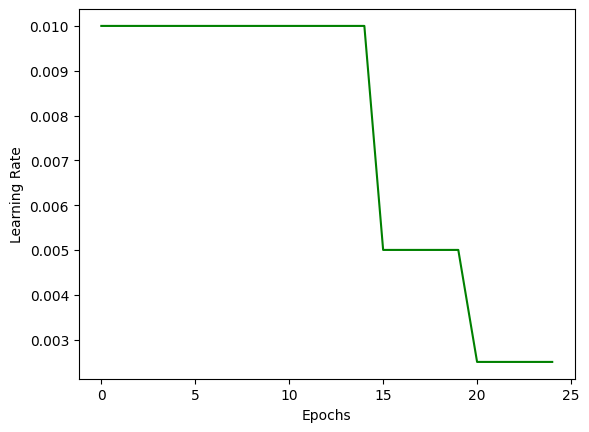

In [17]:
plt.plot(learning_rates, color = 'green')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [18]:
accu_epochs_train[24]

0.9759666919708252

In [19]:
accu_epochs_test[24]

0.9283999800682068

We achieved almost the same performance as AlexNet, at 92% accuracy on the test set (although we could probably do a bit better if we trained for more than 25 epochs). Let us now try a simplified model that is still based on the VGGNet architecture, designed for the original image size of 28x28.

In [20]:
transforms_fashion_mnist =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist)

In [21]:
layer_summary(VGG(VGG_arch = ((2,64),(2,128)), num_full = 2048, num_classes = 10),(1,1,28,28))

Sequential output shape:	 torch.Size([1, 64, 14, 14])
Sequential output shape:	 torch.Size([1, 128, 7, 7])
Flatten output shape:	 torch.Size([1, 6272])
Linear output shape:	 torch.Size([1, 2048])
ReLU output shape:	 torch.Size([1, 2048])
Dropout output shape:	 torch.Size([1, 2048])
Linear output shape:	 torch.Size([1, 2048])
ReLU output shape:	 torch.Size([1, 2048])
Dropout output shape:	 torch.Size([1, 2048])
Linear output shape:	 torch.Size([1, 10])


In [22]:
VGGNet11_red_cuda = VGG(VGG_arch = ((2,64),(2,128)), num_full = 2048, num_classes = 10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
VGGNet11_red_cuda(x);

The number of parameters is much lower.

In [23]:
sum(p.numel() for p in VGGNet11_red_cuda.parameters() if p.requires_grad)

17322954

In [24]:
fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False) 

torch.manual_seed(123)
VGGNet11_red_cuda.apply(init_weights_he) 
optim_SGD_cuda =  torch.optim.SGD(VGGNet11_red_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.005)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[25, 40], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss()

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)
loss = nn.CrossEntropyLoss()

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, VGGNet11_red_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

573.8976550102234


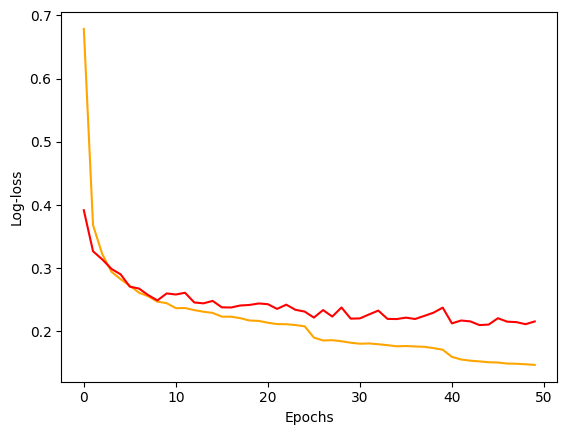

In [25]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

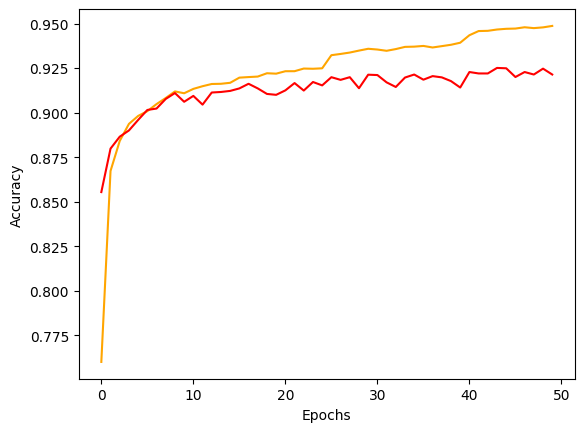

In [26]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

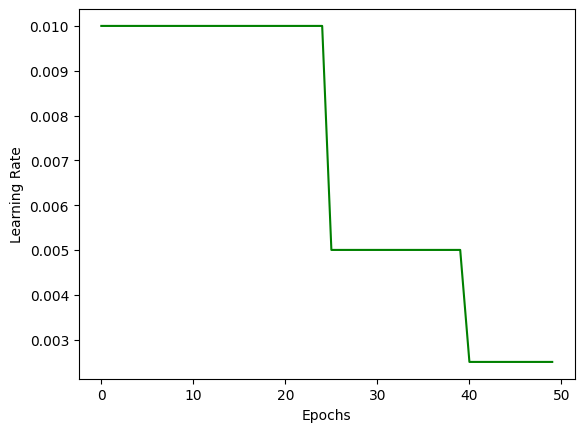

In [27]:
plt.plot(learning_rates, color = 'green')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [28]:
accu_epochs_train[49]

0.9486833214759827

In [29]:
accu_epochs_test[49]

0.9213999509811401

We again got the same accuracy of 92%. Let us try to do a bit better and use image augmentation.

In [30]:
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [28, 28], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = True) 

In [31]:
fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False) 

torch.manual_seed(123)
VGGNet11_red_cuda.apply(init_weights_he) 
optim_SGD_cuda =  torch.optim.SGD(VGGNet11_red_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[25, 40], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss()

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)
loss = nn.CrossEntropyLoss()

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, VGGNet11_red_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1376.8324031829834


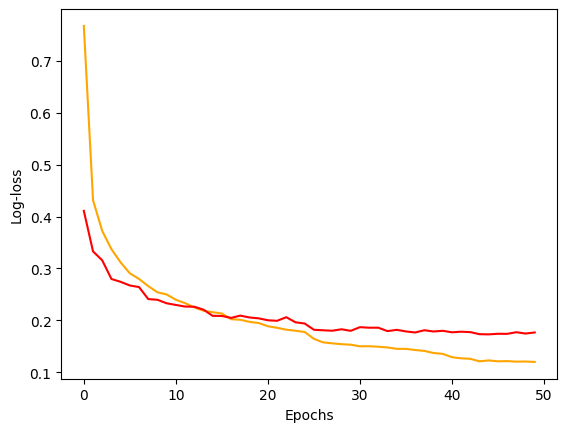

In [32]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

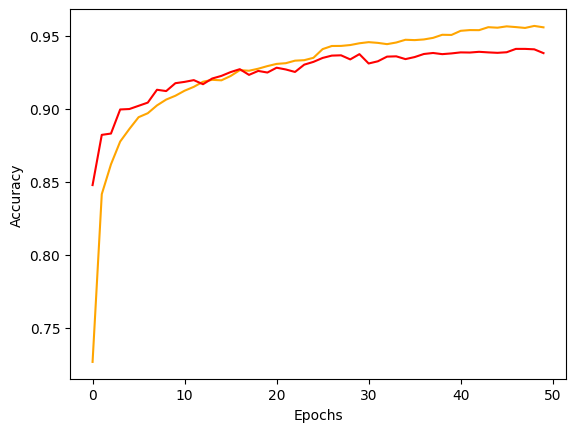

In [33]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

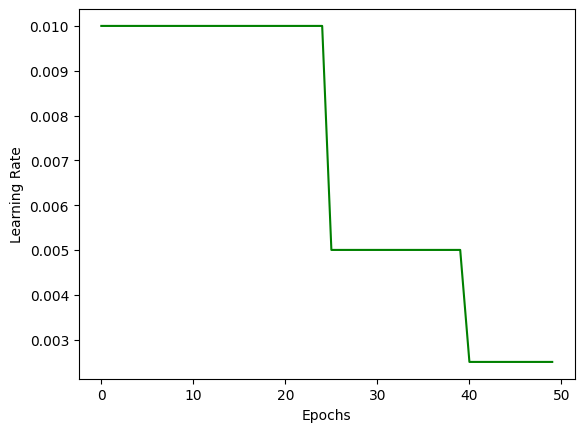

In [34]:
plt.plot(learning_rates, color = 'green')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [35]:
accu_epochs_train[49]

0.9557666778564453

In [36]:
accu_epochs_test[49]

0.9380999803543091

We improved the accuracy to almost 94% on the test dataset.

### Training VGGNet on CIFAR-10 <a class="anchor" id="vggnet_cifar_10"></a>

We will move to the CIFAR-10 dataset next (https://www.cs.toronto.edu/~kriz/cifar.html). Again, we will use the original VGGNet-11 model first.

In [38]:
transforms_cifar10 =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([224,224]),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10)

cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 250, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 250, shuffle = False)

In [39]:
VGGNet11_cuda = VGG(VGG_arch = ((1,64),(1,128),(2,256),(2,512),(2,512)), num_full = 4096, num_classes = 10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
VGGNet11_cuda(x);

In [40]:
cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 100, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 100, shuffle = False)

torch.manual_seed(123)
VGGNet11_cuda.apply(init_weights_he) 
optim_SGD_cuda =  torch.optim.SGD(VGGNet11_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.005)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[15, 20], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss()

n_epochs = 25

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)
loss = nn.CrossEntropyLoss()

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, VGGNet11_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

3580.65319275856


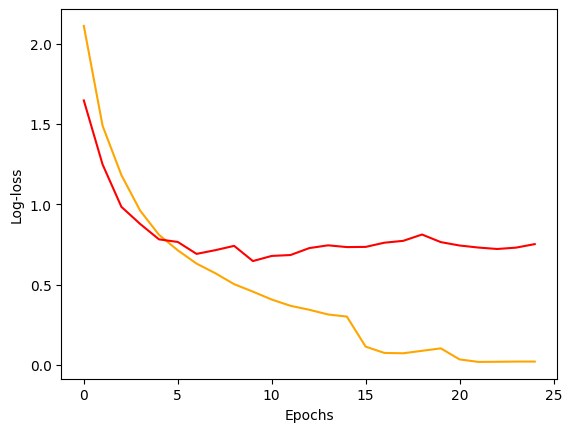

In [41]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

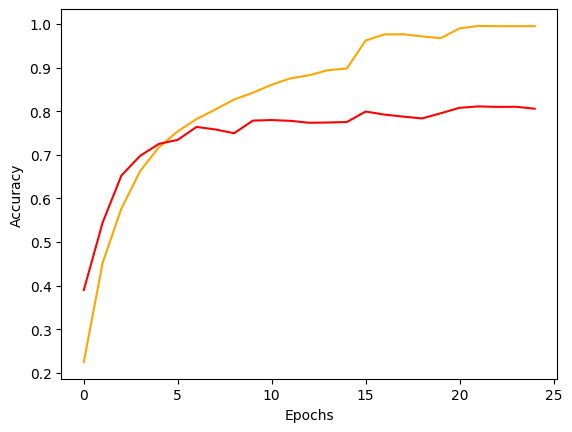

In [42]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

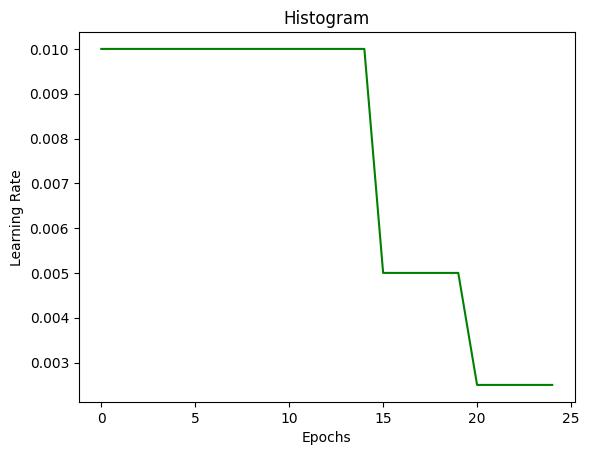

In [43]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [44]:
accu_epochs_train[24]

0.9949199557304382

In [45]:
accu_epochs_test[24]

0.8057000041007996

Again, the accuracy is comparable to that of the AlexNet model. Let us leverage VGGNet's greater modularity and use an architecture better suited to our 32x32 images. We will also include the image augmentation right away, since it already proved beneficial in the previous project.

In [46]:
transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[32,32], scale = [0.8,1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)

In [47]:
VGGNet11_red_cuda = VGG(VGG_arch = ((3,64),(3,128),(3,256)), num_full = 2048, num_classes = 10).eval()
x = (cifar10_train.__getitem__(0)[0])
x = x[None,:,:,:]
VGGNet11_red_cuda(x);

In [48]:
layer_summary(VGGNet11_red_cuda,(1,3,32,32))

Sequential output shape:	 torch.Size([1, 64, 16, 16])
Sequential output shape:	 torch.Size([1, 128, 8, 8])
Sequential output shape:	 torch.Size([1, 256, 4, 4])
Flatten output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 2048])
ReLU output shape:	 torch.Size([1, 2048])
Dropout output shape:	 torch.Size([1, 2048])
Linear output shape:	 torch.Size([1, 2048])
ReLU output shape:	 torch.Size([1, 2048])
Dropout output shape:	 torch.Size([1, 2048])
Linear output shape:	 torch.Size([1, 10])


In [49]:
VGGNet11_red_cuda.to(cuda_device)
cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 100, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 100, shuffle = False)

torch.manual_seed(123)
VGGNet11_red_cuda.apply(init_weights_he) 
optim_SGD_cuda =  torch.optim.SGD(VGGNet11_red_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.005)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[40,60,80], gamma=0.5)
cross_entropy_loss = nn.CrossEntropyLoss()

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)
loss = nn.CrossEntropyLoss()

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, VGGNet11_red_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

2798.152912378311


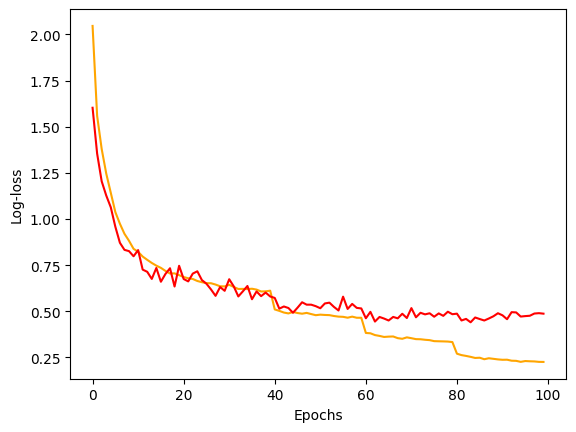

In [50]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

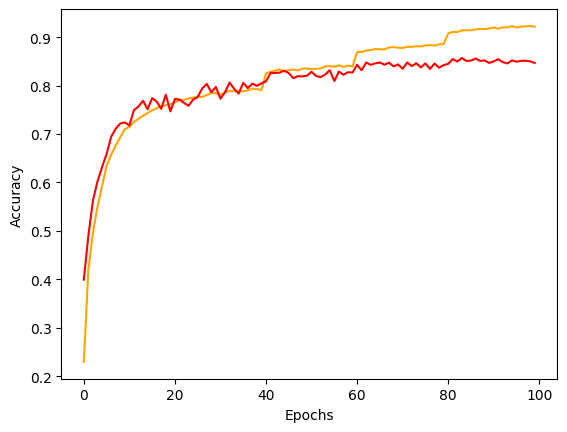

In [51]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

In [52]:
accu_epochs_train[49]

0.835159957408905

In [53]:
accu_epochs_test[49]

0.8203999996185303

We improved the accuarcy metric on the test dataset slightly, but we can do even better.

## Batch Normalization <a class="anchor" id="batch_norm"></a> 

Batch normalization is a learning technique that has been empirically shown to significantly aid the training of deep neural networks [[4](#4), [5](#5)]. As the name suggests, batch normalization normalizes the internal inputs/outputs across layers. It was demonstrated that this smoothens the loss and its gradient, increasing the speed of convergence of MBGD [[6](#6)].

The batch normalization for a feature $x$ is given as follows [[5](#5)]
$$ y = \gamma\frac{x - \mathrm{E}x}{\sqrt{\text{Var }x + \varepsilon}} +  \beta,$$
where $\varepsilon$ is a small constant (e.g., $\varepsilon = 10^{-5}$),  $\gamma$ and $\beta$ are parameters learned during the training from the data, and $\mathrm{E}x$ and $\text{Var }x$ are estimated from the current batch of the data. We should note that *PyTorch* learns running estimates of the mean and variance to predict outputs for new observations. The batch normalization is usually put between the linear layer and the activation function [[5](#5)]
$$ y = h(w^Tx) \rightarrow y = h(\text{BN}(w^Tx)).$$


Let us augment our VGGNet model by adding batch normalization within the convolutional blocks.

In [54]:
def VGG_block_bn(num_convs, out_channels):
    layers = []
    for _ in range(num_convs):
        layers.append(nn.LazyConv2d(out_channels, kernel_size = 3, padding = 1))
        layers.append(nn.LazyBatchNorm2d())
        layers.append(nn.ReLU())
    layers.append(nn.MaxPool2d(kernel_size = 2,stride = 2))
    return nn.Sequential(*layers)

In [55]:
class VGG_bn(nn.Module):
    def __init__(self, VGG_arch, num_full, num_classes):
        super().__init__()
        
        vgg_blocks = []
        for (num_convs, out_channels) in VGG_arch:
            vgg_blocks.append(VGG_block_bn(num_convs, out_channels))
            
        self.net_stack = nn.Sequential(
            *vgg_blocks, nn.Flatten(),
            nn.LazyLinear(num_full), nn.ReLU(), nn.Dropout(0.5),
            nn.LazyLinear(num_full), nn.ReLU(), nn.Dropout(0.5),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [56]:
VGGNet11_red_bn_cuda = VGG_bn(VGG_arch = ((3,64),(3,128),(3,256)), num_full = 2048, num_classes = 10).eval()
x = (cifar10_train.__getitem__(0)[0])
x = x[None,:,:,:]
VGGNet11_red_bn_cuda(x);
VGGNet11_red_bn_cuda.to(cuda_device);

In [57]:
cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 100, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 100, shuffle = False)

torch.manual_seed(123)
VGGNet11_red_bn_cuda.apply(init_weights_he) 
optim_SGD_cuda =  torch.optim.SGD(VGGNet11_red_bn_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.005)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[40,60,70,80,90], gamma=0.5)
cross_entropy_loss = nn.CrossEntropyLoss()

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)
loss = nn.CrossEntropyLoss()

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, VGGNet11_red_bn_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

2883.8428089618683


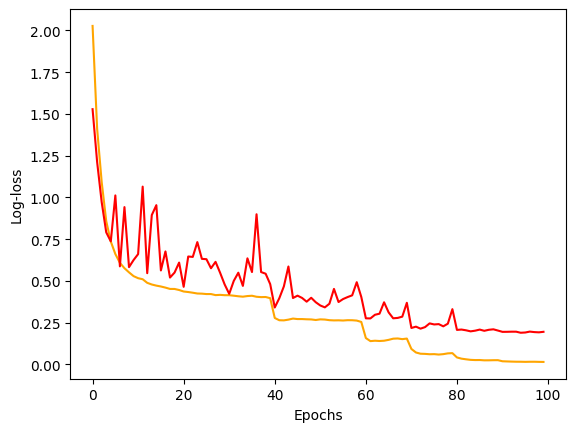

In [58]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

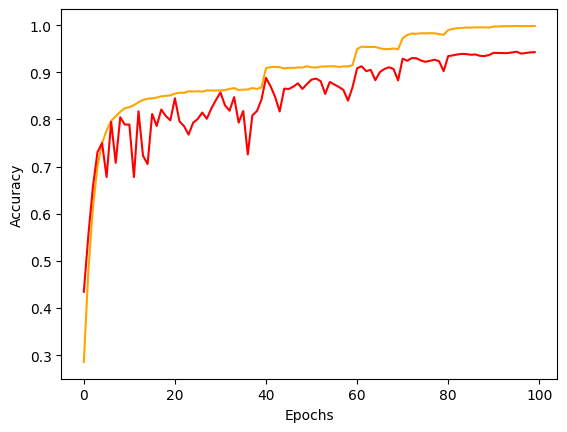

In [59]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

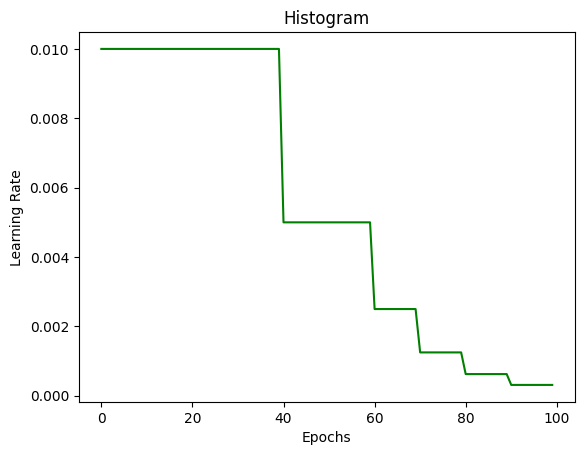

In [60]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [61]:
accu_epochs_train[99]

0.9984999895095825

In [62]:
accu_epochs_test[99]

0.9429000020027161

Batch normalization helped us to reduce test error immensely, resulting in the best model we have achieved on the CIFAR-10 dataset so far.

## References <a class="anchor" id="references"></a>

<a id="1">[1]</a> KRIZHEVSKY, Alex; SUTSKEVER, Ilya; HINTON, Geoffrey E. Imagenet classification with deep convolutional neural networks. *Advances in neural information processing systems*, 2012, 25.

<a id="2">[2]</a> SIMONYAN, Karen; ZISSERMAN, Andrew. Very deep convolutional networks for large-scale image recognition. *arXiv preprint arXiv:1409.1556*, 2014.

<a id="3">[3]</a> XIAO, Han; RASUL, Kashif; VOLLGRAF, Roland. Fashion-mnist: a novel image dataset for benchmarking machine learning algorithms. arXiv preprint arXiv:1708.07747, 2017.

<a id="4">[4]</a> IOFFE, Sergey; SZEGEDY, Christian. Batch normalization: Accelerating deep network training by reducing internal covariate shift. In: *International conference on machine learning.* 2015. p. 448-456.

<a id="5">[5]</a> ZHANG, Aston, et al. *Dive into deep learning*. Cambridge University Press, 2023.

<a id="6">[6]</a> SANTURKAR, Shibani, et al. How does batch normalization help optimization?. Advances in neural information processing systems, 2018, 31.